In [1]:
from astropy.io import fits
from astropy.table import Table

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import pandas as pd
import treecorr

import os
import sys

from tqdm import tqdm

In [2]:
t = Table.read(
    "/user/p5_group/MeharChawla/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO3_Nz.asc",
    format="ascii"
)

print(t)
print(t.colnames)

        col1                 col2        
------------------- ---------------------
                0.0 0.0008788164313366842
               0.05 0.0007073055726113152
                0.1  0.005092371438629243
0.15000000000000002  0.011032726413646672
                0.2  0.019577312294074087
               0.25  0.026971717494000538
0.30000000000000004  0.054414292832105804
0.35000000000000003   0.04453209789466192
                0.4  0.049201337658771375
               0.45   0.07836581862494507
                ...                   ...
                5.5                   0.0
  5.550000000000001                   0.0
 5.6000000000000005                   0.0
               5.65                   0.0
                5.7                   0.0
               5.75                   0.0
  5.800000000000001                   0.0
 5.8500000000000005                   0.0
                5.9                   0.0
               5.95                   0.0
Length = 120 rows
['col1', 'col2']

In [3]:
# The KiDS tomographic demarcations
z_tomo_thresholds = [
    [0.1, 0.3],
    [0.3, 0.5],
    [0.5, 0.7],
    [0.7, 0.9],
    [0.9, 1.2]
]

Tomographic bin-0 - area is 0.049829818840774406
Tomographic bin-1 - area is 0.04996697254378173
Tomographic bin-2 - area is 0.04997802958921659
Tomographic bin-3 - area is 0.04998783562045754
Tomographic bin-4 - area is 0.05


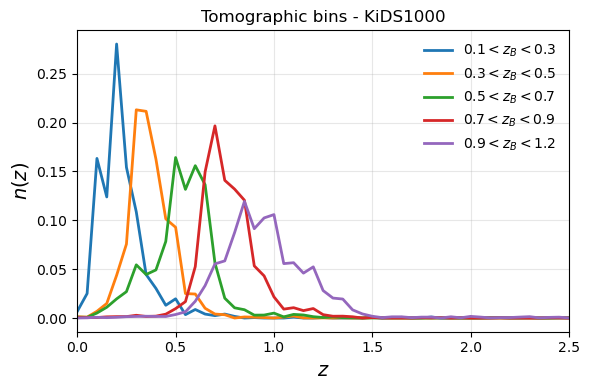

In [4]:
# Directory containing the n(z) files
nz_dir = "/user/p5_group/MeharChawla/KiDS1000/SOM_N_of_Z"

plt.figure(figsize=(6, 4))

for i in range(5):

    filename = f"{nz_dir}/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO{i+1}_Nz.asc"

    # Read the n(z) file
    nz = Table.read(filename, format="ascii")
    nz.rename_columns(["col1", "col2"], ["z", "nz"])

    # Plot
    plt.plot(nz["z"], nz["nz"], linewidth = 2, label = rf"${z_tomo_thresholds[i][0]} < z_B < {z_tomo_thresholds[i][1]}$")
    area = np.trapezoid(nz["nz"], nz["z"])
    print(f"Tomographic bin-{i} - area is {area}")

plt.title("Tomographic bins - KiDS1000")
plt.xlabel(r"$z$", fontsize = 14)
plt.ylabel(r"$n(z)$", fontsize = 14)
plt.xlim(0, 2.5)
plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

Tomographic bin-0 - area is 0.049829818840774406
Tomographic bin-1 - area is 0.04996697254378173
Tomographic bin-2 - area is 0.04997802958921659
Tomographic bin-3 - area is 0.04998783562045754
Tomographic bin-4 - area is 0.05


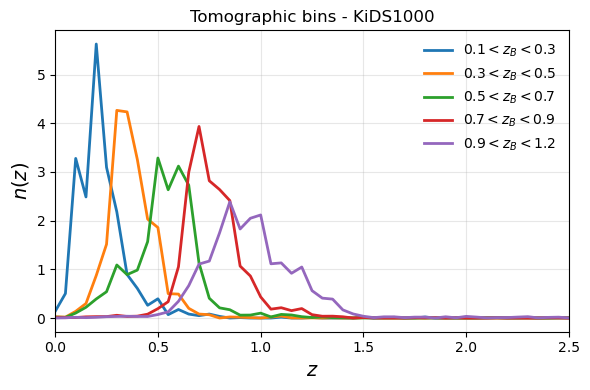

In [5]:
# Directory containing the n(z) files
nz_dir = "/user/p5_group/MeharChawla/KiDS1000/SOM_N_of_Z"

plt.figure(figsize=(6, 4))

for i in range(5):

    filename = f"{nz_dir}/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO{i+1}_Nz.asc"

    # Read the n(z) file
    nz = Table.read(filename, format="ascii")
    nz.rename_columns(["col1", "col2"], ["z", "nz"])

    # Plot
    area = np.trapezoid(nz["nz"], nz["z"])
    plt.plot(nz["z"], nz["nz"] / area, linewidth = 2, label = rf"${z_tomo_thresholds[i][0]} < z_B < {z_tomo_thresholds[i][1]}$")
    print(f"Tomographic bin-{i} - area is {area}")

plt.title("Tomographic bins - KiDS1000")
plt.xlabel(r"$z$", fontsize = 14)
plt.ylabel(r"$n(z)$", fontsize = 14)
plt.xlim(0, 2.5)
plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.savefig(fname = "/user/p5_group/MeharChawla/icts2026/Mehar-Chawla/Tomographic_bins.PDF", )
plt.show()

Tomographic bin-0 - true area is [np.float64(0.049829818840774406)]
Tomographic bin-0 - relevant area is [np.float64(0.020967547267223482)]
Tomographic bin-1 - true area is [np.float64(0.049829818840774406), np.float64(0.04996697254378173)]
Tomographic bin-1 - relevant area is [np.float64(0.020967547267223482), np.float64(0.031418882334535055)]
Tomographic bin-2 - true area is [np.float64(0.049829818840774406), np.float64(0.04996697254378173), np.float64(0.04997802958921659)]
Tomographic bin-2 - relevant area is [np.float64(0.020967547267223482), np.float64(0.031418882334535055), np.float64(0.014492155193691734)]
Tomographic bin-3 - true area is [np.float64(0.049829818840774406), np.float64(0.04996697254378173), np.float64(0.04997802958921659), np.float64(0.04998783562045754)]
Tomographic bin-3 - relevant area is [np.float64(0.020967547267223482), np.float64(0.031418882334535055), np.float64(0.014492155193691734), np.float64(0.025911210056125216)]
Tomographic bin-4 - true area is [np.f

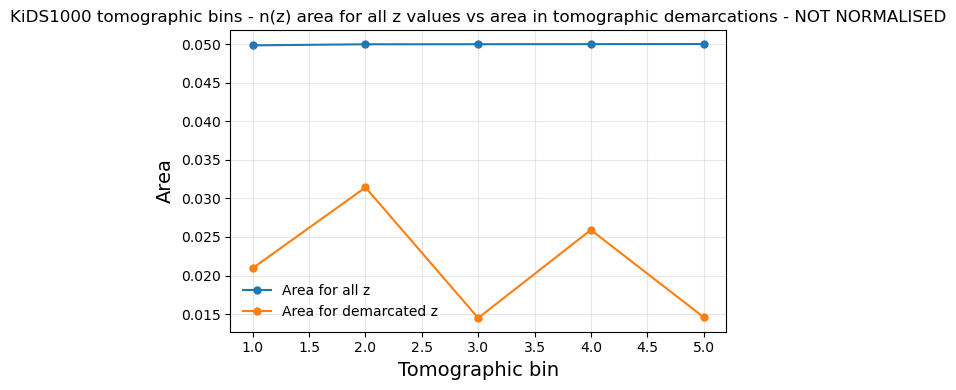

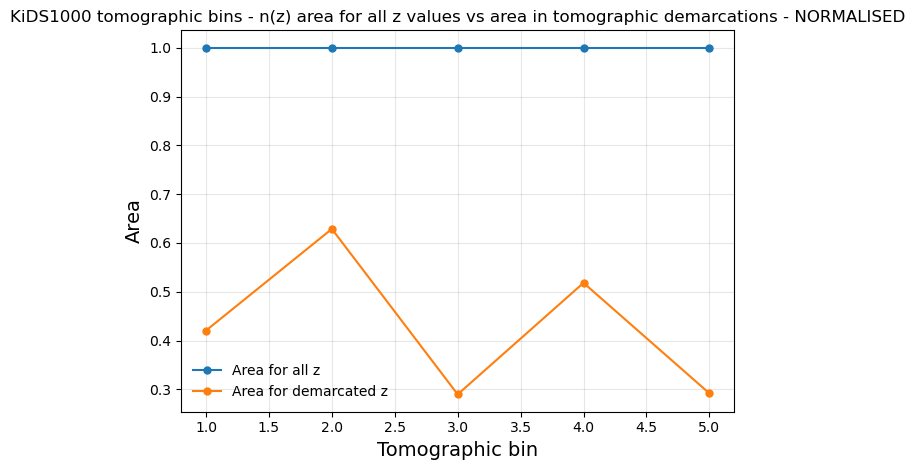

In [6]:
# Directory containing the n(z) files
nz_dir = "/user/p5_group/MeharChawla/KiDS1000/SOM_N_of_Z"

plt.figure(figsize=(6, 4))

x_vals = [1, 2, 3, 4, 5]
true_area = []
relevant_area = []

for i in range(5):
    filename = f"{nz_dir}/K1000_NS_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_SOMcols_Fid_blindC_TOMO{i+1}_Nz.asc"

    # Read the n(z) file
    nz = Table.read(filename, format="ascii")
    nz.rename_columns(["col1", "col2"], ["z", "nz"])

    true_area.append(np.trapezoid(nz["nz"], nz["z"]))
    print(f"Tomographic bin-{i} - true area is {true_area}")

    # Mask to only the fixed demarcations
    zmin, zmax = z_tomo_thresholds[i]
    mask = (nz['z'] > zmin) & (nz['z'] <= zmax)

    relevant_area.append(np.trapezoid(nz["nz"][mask], nz["z"][mask]))
    print(f"Tomographic bin-{i} - relevant area is {relevant_area}")

true_area = np.array(true_area)
relevant_area = np.array(relevant_area)

plt.plot(x_vals, true_area, marker = '.', markersize = 10, label = 'Area for all z')
plt.plot(x_vals, relevant_area, marker = '.', markersize = 10, label = 'Area for demarcated z')
plt.title("KiDS1000 tomographic bins - n(z) area for all z values vs area in tomographic demarcations - NOT NORMALISED")
plt.xlabel("Tomographic bin", fontsize = 14)
plt.ylabel("Area", fontsize = 14)
# plt.xlim(0, 2.5)
plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()


plt.plot(x_vals, true_area / true_area, marker = '.', markersize = 10, label = 'Area for all z')
plt.plot(x_vals, relevant_area / true_area, marker = '.', markersize = 10, label = 'Area for demarcated z')
plt.title("KiDS1000 tomographic bins - n(z) area for all z values vs area in tomographic demarcations - NORMALISED")
plt.xlabel("Tomographic bin", fontsize = 14)
plt.ylabel("Area", fontsize = 14)
# plt.xlim(0, 2.5)
plt.legend(frameon = False)
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()



In [8]:
# treecorr.GGCorrelation?
with fits.open("/user/p5_group/MeharChawla/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits") as hdul:
    print(hdul.info())
    print(len(hdul[1].data))
    print("\n", hdul[1].header)
    df = Table(hdul[1].data).to_pandas()

Filename: /user/p5_group/MeharChawla/KiDS_DR4.1_ugriZYJHKs_SOM_gold_WL_cat.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU    1375   ()      
  1  OBJECTS       1 BinTableHDU    707   21262011R x 193C   [1J, 1J, 1J, 25A, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 1I, 1I, 1I, 1I, 1I, 1D, 1D, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1D, 1D, 1E, 1E, 1E, 1E, 1D, 1D, 1I, 1J, 1I, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1I, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1D, 1J, 1J, 1J, 1J, 1J, 1J, 1E, 1J, 16A, 1I, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1J, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E, 1E,

In [9]:
df.head()

,SeqNr,SLID,SID,ID,FLUX_AUTO,FLUXERR_AUTO,MAG_AUTO,MAGERR_AUTO,KRON_RADIUS,BackGr,...,PSF_e2_exp3,PSF_e1_exp4,PSF_e2_exp4,PSF_e1_exp5,PSF_e2_exp5,SeqNr_field,THELI_INT,e1,e2,weight
0,1,55071011,7667,KIDS_J083427.36-015753.4,0.790356,0.168567,24.965441,0.231623,6.104664,-0.003400,...,0.0020,0.0109,0.0046,99.0,99.0,7668,4,0.0985,0.4712,0.7116
1,4,55071011,8473,KIDS_J083426.91-015731.5,35.463940,0.397274,20.835529,0.012166,3.500000,-0.003398,...,0.0016,0.0113,0.0046,99.0,99.0,8474,4,0.2575,-0.2951,15.5395
2,5,55071011,8828,KIDS_J083427.39-015721.9,4.883646,0.293224,22.988140,0.065206,3.500000,-0.003406,...,0.0015,0.0114,0.0046,99.0,99.0,8829,4,-0.1248,0.1642,14.4574
3,7,55071011,9411,KIDS_J083427.61-015704.0,3.104845,0.345619,23.479900,0.120889,6.541485,-0.002570,...,0.0012,0.0116,0.0047,99.0,99.0,9412,4,0.1859,-0.1807,6.7614
4,10,55071011,97551,KIDS_J083433.20-011433.1,3.603573,0.193368,23.318171,0.058275,3.500000,-0.003093,...,-0.0080,99.0000,99.0000,99.0,99.0,97552,4,-0.2782,0.1826,9.4653


In [26]:
df.columns.tolist()

['SeqNr',
 'SLID',
 'SID',
 'ID',
 'FLUX_AUTO',
 'FLUXERR_AUTO',
 'MAG_AUTO',
 'MAGERR_AUTO',
 'KRON_RADIUS',
 'BackGr',
 'Level',
 'MU_THRESHOLD',
 'MaxVal',
 'MU_MAX',
 'ISOAREA_WORLD',
 'Xpos',
 'Ypos',
 'RAJ2000',
 'DECJ2000',
 'A_WORLD',
 'B_WORLD',
 'THETA_J2000',
 'THETA_WORLD',
 'ERRA_WORLD',
 'ERRB_WORLD',
 'ERRTHETA_J2000',
 'ERRTHETA_WORLD',
 'FWHM_IMAGE',
 'FWHM_WORLD',
 'Flag',
 'FLUX_RADIUS',
 'CLASS_STAR',
 'EXTINCTION_u',
 'EXTINCTION_g',
 'EXTINCTION_r',
 'EXTINCTION_i',
 'PAgaap',
 'MAG_ISO',
 'MAGERR_ISO',
 'FLUX_ISO',
 'FLUXERR_ISO',
 'MAG_ISOCOR',
 'MAGERR_ISOCOR',
 'FLUX_ISOCOR',
 'FLUXERR_ISOCOR',
 'NIMAFLAGS_ISO',
 'IMAFLAGS_ISO',
 'XMIN_IMAGE',
 'YMIN_IMAGE',
 'XMAX_IMAGE',
 'YMAX_IMAGE',
 'X_WORLD',
 'Y_WORLD',
 'X2_WORLD',
 'Y2_WORLD',
 'XY_WORLD',
 'ERRX2_WORLD',
 'ERRY2_WORLD',
 'ERRXY_WORLD',
 'CXX_WORLD',
 'CYY_WORLD',
 'CXY_WORLD',
 'ERRCXX_WORLD',
 'ERRCYY_WORLD',
 'ERRCXY_WORLD',
 'A_IMAGE',
 'B_IMAGE',
 'ERRA_IMAGE',
 'ERRB_IMAGE',
 'S_ELLIPTICITY',
 

In [27]:
df['weight']

0            0.7116
1           15.5395
2           14.4574
3            6.7614
4            9.4653
             ...   
21262006     7.4016
21262007    12.6046
21262008    15.4484
21262009    15.0339
21262010     7.0869
Name: weight, Length: 21262011, dtype: float32

In [12]:
print(df[["Z_B", "Z_B_MIN", "Z_B_MAX"]].head())
print(df.shape[0]) # Number of rows
print(z_tomo_thresholds)

    Z_B  Z_B_MIN  Z_B_MAX
0  0.71     0.45     1.32
1  0.44     0.40     0.46
2  1.08     1.00     1.16
3  0.54     0.39     0.84
4  1.01     0.94     1.06
21262011
[[0.1, 0.3], [0.3, 0.5], [0.5, 0.7], [0.7, 0.9], [0.9, 1.2]]


In [ ]:
#count the number of galaxies in each tomographic bin and make a catalog of their coordinates
for i in range (5):
    z_range = z_tomo_thresholds[i]
    count = 0
    for j in tqdm(range(df.shape[0])):
        if (df['Z_B'][j] > z_range[0]) and (df['Z_B'][j] <= z_range[1]): count += 1
    print(f"Number of galaxies in the {z_range} tomographic bin is {count}")


In [ ]:
#Calculating n_eff
A = 777.4 * 3600 # to convert to arcmin^2
for i in range (5):
    z_range = z_tomo_thresholds[i]
    count = 0
    Sum_w = 0
    Sum_w_sq = 0
    for j in range(df.shape[0]):
        if (df['Z_B'][j] > z_range[0]) and (df['Z_B'][j] <= z_range[1]): 
            count += 1
            w = df['weight'][j]
            Sum_w = Sum_w + w
            Sum_w_sq = Sum_w_sq + (w * w)
    n_eff = (1.0 / A) * ((Sum_w * Sum_w) / Sum_w_sq)
    print(f"n_eff for {z_range} tomographic bin is {n_eff}")

In [ ]:
# #2PCF calculation for a single tomographic bin


# cat = treecorr.Catalog('cat.fits', ra_col = 'RAJ2000', dec_col = 'DECJ2000', ra_units = 'degrees', dec_units = 'degrees', g1_col = 'GAMMA1', g2_col = 'GAMMA2')
# gg = treecorr.GGCorrelation(min_sep = 1., max_sep = 100., bin_size = 0.1, sep_units = 'arcmin')
# gg.process(cat)
# xip = gg.xip  # The xi_plus correlation function
# xim = gg.xim  # The xi_minus correlation function

In [ ]:
# Making .fits files for the 5 different tomographic bin galaxy samples
output_dir = "/user/p5_group/MeharChawla/KiDS1000"

for i, (zmin, zmax) in tqdm(enumerate(z_tomo_thresholds, start = 1)):
    tomo_df = df[(df["Z_B"] > zmin) & (df["Z_B"] <= zmax)]
    print(f"TOMO{i}: {len(tomo_df)} galaxies")
    tomo_table = Table.from_pandas(tomo_df)

    filename = f"{output_dir}/KiDS1000_TOMO{i}.fits"
    tomo_table.write(filename, overwrite=True)

In [ ]:
treecorr.Catalog?

In [10]:
#2PCF for individual tomographic bins

ggSuperCat_single_tomo = []
for i in tqdm(range(5)):
    print(f'Calculating 2PCF for tomographic bin-{i + 1}')
    cat = treecorr.Catalog(f'/user/p5_group/MeharChawla/KiDS1000/KiDS1000_TOMO{i+1}.fits', ra_col = 'RAJ2000', dec_col = 'DECJ2000', ra_units = 'degrees', dec_units = 'degrees', g1_col = 'e1', g2_col = 'e2', w_col = 'weight')
    gg = treecorr.GGCorrelation(min_sep = 0.5, max_sep = 300., nbins = 9, sep_units = 'arcmin')
    gg.process(cat)
    ggSuperCat_single_tomo.append(gg)
    print(f'Finished calculating 2PCF for tomographic bin-{i + 1}')
    # print(f"Number of galaxies in the {z_range} tomographic bin is {count}")

  0%|                                                                                                     | 0/5 [00:00<?, ?it/s]

Calculating 2PCF for tomographic bin-1


 20%|██████████████████▌                                                                          | 1/5 [00:04<00:17,  4.29s/it]

Finished calculating 2PCF for tomographic bin-1
Calculating 2PCF for tomographic bin-2


 40%|█████████████████████████████████████▏                                                       | 2/5 [00:15<00:25,  8.53s/it]

...

Finished calculating 2PCF for tomographic bin-3
Calculating 2PCF for tomographic bin-4


 80%|██████████████████████████████████████████████████████████████████████████▍                  | 4/5 [00:47<00:13, 13.41s/it]

Finished calculating 2PCF for tomographic bin-4
Calculating 2PCF for tomographic bin-5


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:59<00:00, 11.84s/it]

Finished calculating 2PCF for tomographic bin-5


In [8]:
# gg.process?
treecorr.GGCorrelation?

Init signature: treecorr.GGCorrelation(config=None, *, logger=None, **kwargs)
Docstring:     
This class handles the calculation and storage of a 2-point shear-shear correlation
function.

See the docstring of `Corr2` for a description of how the pairs are binned along
with the attributes related to the different binning options.

In addition to the attributes common to all `Corr2` subclasses, objects of this class
hold the following attributes:

Attributes:

    xip:        The correlation function, :math:`\xi_+(r)`.
    xim:        The correlation function, :math:`\xi_-(r)`.
    xip_im:     The imaginary part of :math:`\xi_+(r)`.
    xim_im:     The imaginary part of :math:`\xi_-(r)`.
    varxip:     An estimate of the variance of :math:`\xi_+(r)`
    varxim:     An estimate of the variance of :math:`\xi_-(r)`
    cov:        An estimate of the full covariance matrix for the data vector with
                :math:`\xi_+` first and then :math:`\xi_-`.

.. note::

    The default metho

[ 1.12500794e-04  1.23404529e-05  5.54452932e-05  4.65723046e-06
 -3.52816977e-07 -2.31138687e-06 -1.10691042e-06  6.81232791e-07
  4.90526250e-07]


 [-2.65076682e-05  5.49747069e-05  2.99135366e-05 -2.00857994e-06
  6.28701938e-06 -4.31765484e-06 -3.47127691e-07  7.37877160e-08
 -5.29816358e-07]


 [  0.78581734   1.59937203   3.25418319   6.62469376  13.50156057
  27.45585985  55.7668589  113.0548228  226.68754127]


 [1.49621200e+06 5.80680000e+06 2.25347080e+07 8.65045690e+07
 3.39757729e+08 1.33173845e+09 5.05034917e+09 1.81285294e+10
 5.43797594e+10]


 [3.04653197e+08 1.18085579e+09 4.57729123e+09 1.75547334e+10
 6.89329234e+10 2.70016951e+11 1.02292869e+12 3.67314247e+12
 1.10101984e+13]


/tmp/ipykernel_609123/3600792178.py:16: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 110)


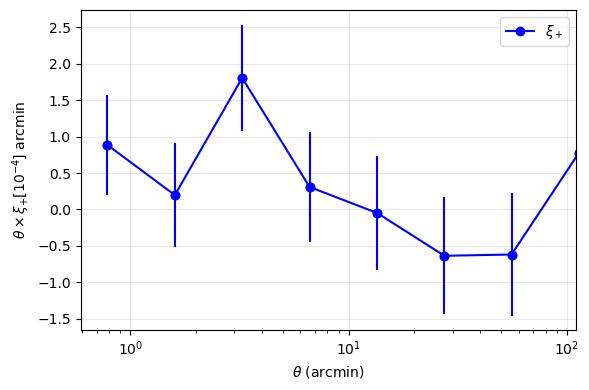

/tmp/ipykernel_609123/3600792178.py:28: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  plt.xlim(0, 110)


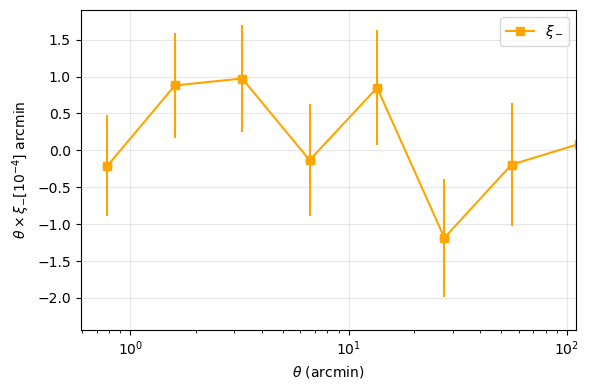

In [11]:
# Testing the waters!

gg_test = ggSuperCat_single_tomo[0]
print(gg_test.xip)      # Psi +
print("\n\n", gg_test.xim)      # Psi -
print("\n\n", gg_test.meanr)    # mean separation
print("\n\n", gg_test.npairs)   # number of pairs
print("\n\n", gg_test.weight)   # pair weights

# psi +
plt.figure(figsize=(6,4))
plt.semilogx(gg_test.meanr, gg_test.meanr * gg_test.xip * 10000, 'o-', label = r'$\xi_+$', color = 'blue')
plt.errorbar(gg_test.meanr, gg_test.meanr * gg_test.xip * 10000, yerr = gg.meanr * 10000.0 * np.sqrt(gg_test.varxip), fmt = 'o', color = 'blue')
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\theta \times \xi_{\plus} [10^{-4}]$ arcmin')
plt.xlim(0, 110)
plt.legend()
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

#psi -
plt.figure(figsize=(6,4))
plt.semilogx(gg_test.meanr, gg_test.meanr * gg_test.xim * 10000, 's-', label = r'$\xi_-$', color = 'orange')
plt.errorbar(gg_test.meanr, gg_test.meanr * gg_test.xim * 10000, yerr = gg.meanr * 10000.0 * np.sqrt(gg_test.varxim), fmt = 'o', color = 'orange')
plt.xlabel(r'$\theta$ (arcmin)')
plt.ylabel(r'$\theta \times \xi_{\minus} [10^{-4}]$ arcmin')
plt.xlim(0, 110)
plt.legend()
plt.grid(alpha = 0.3)
plt.tight_layout()
plt.show()

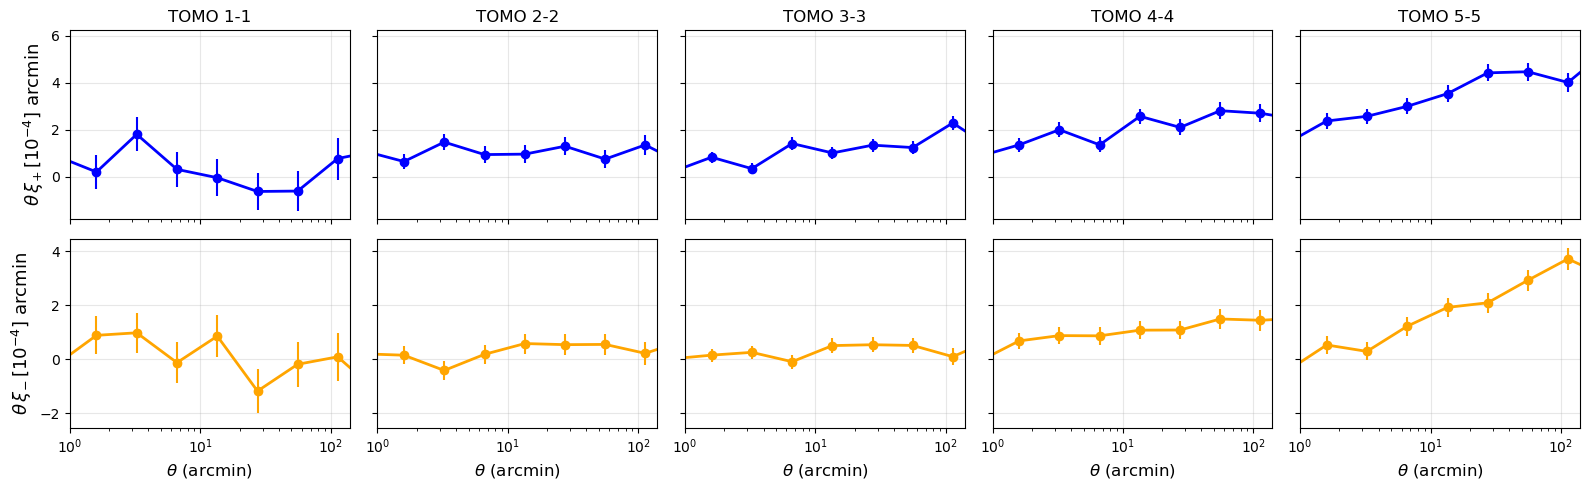

In [12]:
fig, ax = plt.subplots(2, 5, figsize = (16, 5), sharex = True, sharey = 'row')

for i in range(5):
    gg = ggSuperCat_single_tomo[i]
    # xi +
    ax[0, i].semilogx(gg.meanr, gg.meanr * gg.xip * 1e4, 'o-', color='blue', linewidth = 2, markersize = 5)
    ax[0, i].errorbar(gg.meanr, gg.meanr * gg.xip * 10000, yerr = gg.meanr * 10000.0 * np.sqrt(gg.varxip), fmt = 'o', color = 'blue')

    ax[0, i].set_title(f"TOMO {i+1}-{i+1}")
    ax[0, i].grid(alpha=0.3)

    # xi -
    ax[1, i].semilogx(gg.meanr, gg.meanr * gg.xim * 1e4, 's-', color = 'orange', linewidth = 2, markersize = 5)
    ax[1, i].errorbar(gg.meanr, gg.meanr * gg.xim * 10000, yerr = gg.meanr * 10000.0 * np.sqrt(gg.varxim), fmt = 'o', color = 'orange')

    ax[1, i].grid(alpha=0.3)

# Axis labels
ax[0, 0].set_ylabel(r'$\theta\,\xi_{+}\,[10^{-4}]$ arcmin', fontsize = 13)
ax[1, 0].set_ylabel(r'$\theta\,\xi_{-}\,[10^{-4}]$ arcmin', fontsize = 13)

for i in range(5):
    ax[1, i].set_xlabel(r'$\theta$ (arcmin)', fontsize = 12)
plt.xlim(1, 140)
plt.tight_layout()
plt.show()

Filename: /user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       4   ()      
  1  COVMAT        1 ImageHDU        13   (270, 270)   float64   
  2  xiP           1 BinTableHDU     29   135R x 5C   [K, K, K, D, D]   
  3  xiM           1 BinTableHDU     29   135R x 5C   [K, K, K, D, D]   
  4  NZ_SOURCE     1 BinTableHDU     36   119R x 8C   [D, D, D, D, D, D, D, D]   
(270, 270)
True
[[7.61755989e-09 1.67773794e-12 1.16065823e-12 ... 8.77729973e-14
  4.79746541e-14 2.72503313e-14]
 [1.67773794e-12 1.95695084e-09 1.10448600e-12 ... 7.18013536e-14
  3.92197291e-14 2.20409033e-14]
 [1.16065823e-12 1.10448600e-12 5.06410377e-10 ... 5.38570895e-14
  2.96060559e-14 1.64761880e-14]
 ...
 [7.64057567e-14 6.55377070e-14 5.07305861e-14 ... 6.06811224e-13
  2.7825

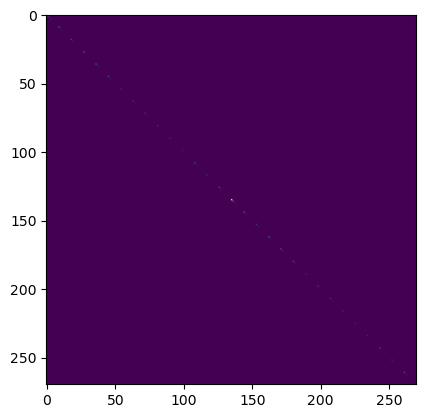

In [13]:
filename = "/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits"

with fits.open(filename) as hdul:
    hdul.info()
    # print(hdul[2].columns)
    # print(hdul[2].data)
    # print(hdul[3].columns)
    # print(hdul[3].data)
    cov = hdul[1].data
    
    print(cov.shape)
    print(np.allclose(cov, cov.T))
    # xip = Table.read(filename, hdu="xiP")
    # xim = Table.read(filename, hdu="xiM")
    
    # print(hdul[1].columns)
    print(hdul[1].data)
    plt.imshow(hdul[1].data)
    
    # print(xip[:20])

In [14]:
with fits.open(filename) as hdul:
    cov = hdul[1].data

print(cov.shape)
print(np.allclose(cov, cov.T))

(270, 270)
True


In [15]:
# The multiplicative bias values from metacallibration, reported in the KiDS paper
m_val = [-0.009, -0.011, -0.015, 0.002, 0.007]
m_err = [0.019, 0.020, 0.017, 0.012, 0.010]

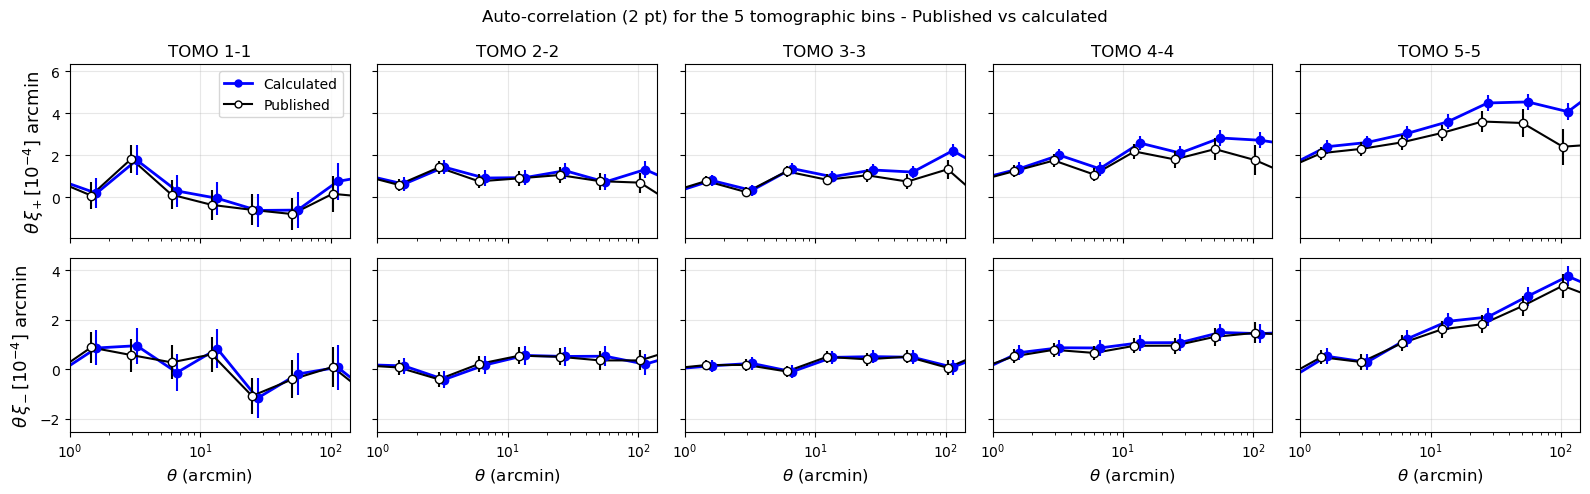

In [16]:
fig, ax = plt.subplots(2, 5, figsize = (16, 5), sharex = True, sharey = 'row')

fname = "/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits"

pub_xip = Table.read(fname, hdu = "xiP")
pub_xim = Table.read(fname, hdu = "xiM")

sigma = np.sqrt(np.diag(cov))
xip_err = sigma[:135]
xim_err = sigma[135:]

for i in range(5):
    gg = ggSuperCat_single_tomo[i]

    """
    starting indices are in jumps
    stored as:
    
    1-1 1-2 1-3 1-4 1-5   (each block is 9 bins long so 9 * 5 = 45 so [0 : 45])
    2-2 2-3 2-4 2-5       (9 * 4 = 36 so [45 : 81])
    3-3 3-4 3-5           (9 * 3 = 27 so [81 : 108])
    4-4 4-5               (9 * 2 = 18 so [108 : 126])
    5-5                   (9 * 1 = 9 so [126 : 135])

    Hence,
    """
    start_indices = [0, 45, 81, 108, 126] 
    
    # Xi+

    # Calculated 2PCF
    ax[0, i].semilogx(gg.meanr, gg.meanr * gg.xip * 1e4 * (1 + m_val[i])**2, 'o-', color = 'blue', linewidth = 2, markersize = 5, label = 'Calculated')
    ax[0, i].errorbar(gg.meanr, gg.meanr * gg.xip * 1e4 * (1 + m_val[i])**2, yerr = gg.meanr * 1e4 * np.sqrt(gg.varxip), fmt = 'o', color = 'blue')

    # Published 2PCF
    mask = (pub_xip["BIN1"] == i + 1) & (pub_xip["BIN2"] == i + 1)
    ax[0, i].semilogx(pub_xip["ANG"][mask], pub_xip["ANG"][mask] * pub_xip["VALUE"][mask] * 1e4, 'ko-', markerfacecolor = 'white', linewidth = 1.5, markersize = 5, label = 'Published')
    ax[0, i].errorbar(pub_xip["ANG"][mask], pub_xip["ANG"][mask] * pub_xip["VALUE"][mask] * 1e4, yerr = pub_xip["ANG"][mask] * 1e4 * xip_err[start_indices[i] : start_indices[i] + 9], fmt = 'o', color = 'black', markerfacecolor = 'white')

    ax[0, i].set_title(f"TOMO {i + 1}-{i + 1}")
    ax[0, i].grid(alpha = 0.3) 

    # Xi-

    # Calculated 2PCF
    ax[1, i].semilogx(gg.meanr, gg.meanr * gg.xim * 1e4 * (1 + m_val[i])**2, 's-', color = 'blue', linewidth = 2, markersize = 5, label = 'Calculated')
    ax[1, i].errorbar(gg.meanr, gg.meanr * gg.xim * 1e4 * (1 + m_val[i])**2, yerr = gg.meanr * 1e4 * np.sqrt(gg.varxim), fmt = 'o', color = 'blue')

    # Published 2PCF
    mask = (pub_xim["BIN1"] == i + 1) & (pub_xim["BIN2"] == i + 1)
    ax[1, i].semilogx(pub_xim["ANG"][mask], pub_xim["ANG"][mask] * pub_xim["VALUE"][mask] * 1e4, 'ko-', markerfacecolor = 'white', linewidth = 1.5, markersize = 5, label = 'Published')
    ax[1, i].errorbar(pub_xim["ANG"][mask], pub_xim["ANG"][mask] * pub_xim["VALUE"][mask] * 1e4, yerr = pub_xim["ANG"][mask] * 1e4 * xim_err[start_indices[i] : start_indices[i] + 9], fmt = 'o', color = 'black', markerfacecolor = 'white')

    ax[1, i].grid(alpha = 0.3)

# Axis labels
ax[0, 0].set_ylabel(r'$\theta\,\xi_{+}\,[10^{-4}]$ arcmin', fontsize = 13)
ax[1, 0].set_ylabel(r'$\theta\,\xi_{-}\,[10^{-4}]$ arcmin', fontsize = 13)
ax[0, 0].legend()

for i in range(5):
    ax[1, i].set_xlabel(r'$\theta$ (arcmin)', fontsize = 12)

plt.suptitle('Auto-correlation (2 pt) for the 5 tomographic bins - Published vs calculated')
plt.xlim(1, 140)
plt.tight_layout()
plt.show()

In [17]:
# Calculating c_1 and c_2 to correct for the c-bias


In [ ]:
# Making new files with the updated ellipticities
# Output directory
output_dir = "/user/p5_group/MeharChawla/KiDS1000"

for i, (zmin, zmax) in tqdm(enumerate(z_tomo_thresholds, start = 1)):
    tomo_df = df[(df["Z_B"] > zmin) & (df["Z_B"] <= zmax)]
    print(f"TOMO{i}: {len(tomo_df)} galaxies")

    e_1 = tomo_df['e1']
    e_2 = tomo_df['e2']
    w = tomo_df['weight']

    c_1 = np.sum(w * e_1) / np.sum(w)
    c_2 = np.sum(w * e_2) / np.sum(w)

    print(f"c1 = {c_1:.6e}, c2 = {c_2:.6e}")

    tomo_df["e_1_c_1"] = e_1 - c_1
    tomo_df["e_2_c_2"] = e_2 - c_2
    
    
    tomo_table = Table.from_pandas(tomo_df)
    filename = f"{output_dir}/KiDS1000_TOMO{i}.fits"
    tomo_table.write(filename, overwrite = True)

In [19]:
#2PCF for individual tomographic bins

ggSuperCat_single_tomo = []
for i in tqdm(range(5)):
    print(f'Calculating 2PCF for tomographic bin-{i + 1}')
    cat = treecorr.Catalog(f'/user/p5_group/MeharChawla/KiDS1000/KiDS1000_TOMO{i+1}.fits', ra_col = 'RAJ2000', dec_col = 'DECJ2000', ra_units = 'degrees', dec_units = 'degrees', g1_col = 'e_1_c_1', g2_col = 'e_2_c_2', w_col = 'weight')
    gg = treecorr.GGCorrelation(min_sep = 0.5, max_sep = 300., nbins = 9, sep_units = 'arcmin')
    gg.process(cat)
    ggSuperCat_single_tomo.append(gg)
    print(f'Finished calculating 2PCF for tomographic bin-{i + 1}')
    # print(f"Number of galaxies in the {z_range} tomographic bin is {count}")

  0%|                                                                                                     | 0/5 [00:00<?, ?it/s]

Calculating 2PCF for tomographic bin-1


 20%|██████████████████▌                                                                          | 1/5 [00:02<00:08,  2.14s/it]

Finished calculating 2PCF for tomographic bin-1
Calculating 2PCF for tomographic bin-2


 40%|█████████████████████████████████████▏                                                       | 2/5 [00:06<00:10,  3.44s/it]

...

Finished calculating 2PCF for tomographic bin-3
Calculating 2PCF for tomographic bin-4


 80%|██████████████████████████████████████████████████████████████████████████▍                  | 4/5 [00:22<00:06,  6.26s/it]

Finished calculating 2PCF for tomographic bin-4
Calculating 2PCF for tomographic bin-5


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:30<00:00,  6.01s/it]

Finished calculating 2PCF for tomographic bin-5


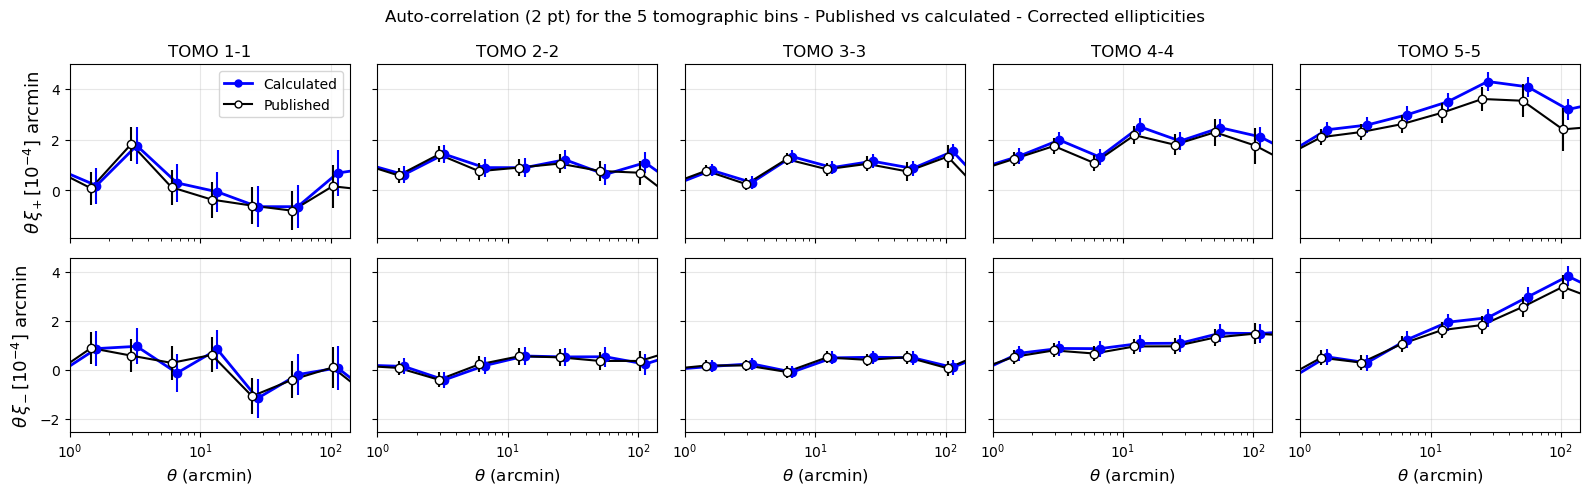

In [20]:
fig, ax = plt.subplots(2, 5, figsize = (16, 5), sharex = True, sharey = 'row')

fname = "/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits"

pub_xip = Table.read(fname, hdu = "xiP")
pub_xim = Table.read(fname, hdu = "xiM")

sigma = np.sqrt(np.diag(cov))
xip_err = sigma[:135]
xim_err = sigma[135:]

for i in range(5):
    gg = ggSuperCat_single_tomo[i]

    """
    starting indices are in jumps
    stored as:
    
    1-1 1-2 1-3 1-4 1-5   (each block is 9 bins long so 9 * 5 = 45 so [0 : 45])
    2-2 2-3 2-4 2-5       (9 * 4 = 36 so [45 : 81])
    3-3 3-4 3-5           (9 * 3 = 27 so [81 : 108])
    4-4 4-5               (9 * 2 = 18 so [108 : 126])
    5-5                   (9 * 1 = 9 so [126 : 135])

    Hence,
    """
    start_indices = [0, 45, 81, 108, 126] 
    
    # Xi+

    # Calculated 2PCF
    ax[0, i].semilogx(gg.meanr, gg.meanr * gg.xip * 1e4 * (1 + m_val[i])**2, 'o-', color = 'blue', linewidth = 2, markersize = 5, label = 'Calculated')
    ax[0, i].errorbar(gg.meanr, gg.meanr * gg.xip * 1e4 * (1 + m_val[i])**2, yerr = gg.meanr * 1e4 * np.sqrt(gg.varxip), fmt = 'o', color = 'blue')

    # Published 2PCF
    mask = (pub_xip["BIN1"] == i + 1) & (pub_xip["BIN2"] == i + 1)
    ax[0, i].semilogx(pub_xip["ANG"][mask], pub_xip["ANG"][mask] * pub_xip["VALUE"][mask] * 1e4, 'ko-', markerfacecolor = 'white', linewidth = 1.5, markersize = 5, label = 'Published')
    ax[0, i].errorbar(pub_xip["ANG"][mask], pub_xip["ANG"][mask] * pub_xip["VALUE"][mask] * 1e4, yerr = pub_xip["ANG"][mask] * 1e4 * xip_err[start_indices[i] : start_indices[i] + 9], fmt = 'o', color = 'black', markerfacecolor = 'white')

    ax[0, i].set_title(f"TOMO {i + 1}-{i + 1}")
    ax[0, i].grid(alpha = 0.3) 

    # Xi-

    # Calculated 2PCF
    ax[1, i].semilogx(gg.meanr, gg.meanr * gg.xim * 1e4 * (1 + m_val[i])**2, 's-', color = 'blue', linewidth = 2, markersize = 5, label = 'Calculated')
    ax[1, i].errorbar(gg.meanr, gg.meanr * gg.xim * 1e4 * (1 + m_val[i])**2, yerr = gg.meanr * 1e4 * np.sqrt(gg.varxim), fmt = 'o', color = 'blue')

    # Published 2PCF
    mask = (pub_xim["BIN1"] == i + 1) & (pub_xim["BIN2"] == i + 1)
    ax[1, i].semilogx(pub_xim["ANG"][mask], pub_xim["ANG"][mask] * pub_xim["VALUE"][mask] * 1e4, 'ko-', markerfacecolor = 'white', linewidth = 1.5, markersize = 5, label = 'Published')
    ax[1, i].errorbar(pub_xim["ANG"][mask], pub_xim["ANG"][mask] * pub_xim["VALUE"][mask] * 1e4, yerr = pub_xim["ANG"][mask] * 1e4 * xim_err[start_indices[i] : start_indices[i] + 9], fmt = 'o', color = 'black', markerfacecolor = 'white')

    ax[1, i].grid(alpha = 0.3)

# Axis labels
ax[0, 0].set_ylabel(r'$\theta\,\xi_{+}\,[10^{-4}]$ arcmin', fontsize = 13)
ax[1, 0].set_ylabel(r'$\theta\,\xi_{-}\,[10^{-4}]$ arcmin', fontsize = 13)
ax[0, 0].legend()

for i in range(5):
    ax[1, i].set_xlabel(r'$\theta$ (arcmin)', fontsize = 12)

plt.suptitle('Auto-correlation (2 pt) for the 5 tomographic bins - Published vs calculated - Corrected ellipticities')
plt.xlim(1, 140)
plt.tight_layout()
plt.show()

In [21]:
#2PCF for cross tomographic bins

ggSuperCat_cross_tomo = []

for i in tqdm(range(5)):
    gg_temp = []
    for j in range(i + 1, 5):
        print(f'Calculating 2PCF for tomographic bin-{i + 1} and tomographic bin-{j + 1}')
        cat1 = treecorr.Catalog(f'/user/p5_group/MeharChawla/KiDS1000/KiDS1000_TOMO{i+1}.fits', ra_col = 'RAJ2000', dec_col = 'DECJ2000', ra_units = 'degrees', dec_units = 'degrees', g1_col = 'e_1_c_1', g2_col = 'e_2_c_2', w_col = 'weight')
        cat2 = treecorr.Catalog(f'/user/p5_group/MeharChawla/KiDS1000/KiDS1000_TOMO{j+1}.fits', ra_col = 'RAJ2000', dec_col = 'DECJ2000', ra_units = 'degrees', dec_units = 'degrees', g1_col = 'e_1_c_1', g2_col = 'e_2_c_2', w_col = 'weight')
        gg = treecorr.GGCorrelation(min_sep = 0.5, max_sep = 300., nbins = 9, sep_units = 'arcmin')
        gg.process(cat1, cat2)
        gg_temp.append(gg)
        print(f'Finished calculating 2PCF for tomographic bin-{i + 1} and tomographic bin-{j + 1}')
    ggSuperCat_cross_tomo.append(gg_temp)
    # print(f"Number of galaxies in the {z_range} tomographic bin is {count}")

  0%|                                                                                                     | 0/5 [00:00<?, ?it/s]

Calculating 2PCF for tomographic bin-1 and tomographic bin-2
Finished calculating 2PCF for tomographic bin-1 and tomographic bin-2
Calculating 2PCF for tomographic bin-1 and tomographic bin-3
Finished calculating 2PCF for tomographic bin-1 and tomographic bin-3
Calculating 2PCF for tomographic bin-1 and tomographic bin-4
Finished calculating 2PCF for tomographic bin-1 and tomographic bin-4
Calculating 2PCF for tomographic bin-1 and tomographic bin-5


 20%|██████████████████▌                                                                          | 1/5 [00:28<01:52, 28.08s/it]

Finished calculating 2PCF for tomographic bin-1 and tomographic bin-5
Calculating 2PCF for tomographic bin-2 and tomographic bin-3
Finished calculating 2PCF for tomographic bin-2 and tomographic bin-3
Calculating 2PCF for tomographic bin-2 and tomographic bin-4
Finished calculating 2PCF for tomographic bin-2 and tomographic bin-4
Calculating 2PCF for tomographic bin-2 and tomographic bin-5


 40%|█████████████████████████████████████▏                                                       | 2/5 [00:59<01:30, 30.08s/it]

Finished calculating 2PCF for tomographic bin-2 and tomographic bin-5
Calculating 2PCF for tomographic bin-3 and tomographic bin-4
Finished calculating 2PCF for tomographic bin-3 and tomographic bin-4
Calculating 2PCF for tomographic bin-3 and tomographic bin-5


 60%|███████████████████████████████████████████████████████▊                                     | 3/5 [01:25<00:56, 28.35s/it]

Finished calculating 2PCF for tomographic bin-3 and tomographic bin-5
Calculating 2PCF for tomographic bin-4 and tomographic bin-5


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:37<00:00, 19.55s/it]

Finished calculating 2PCF for tomographic bin-4 and tomographic bin-5


In [22]:
# for i in range(5):
#     print(len(ggSuperCat_cross_tomo[i]))

fname = "/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits"

pub_xip = Table.read(fname, hdu = "xiP")
pub_xim = Table.read(fname, hdu = "xiM")

sigma = np.sqrt(np.diag(cov))
xip_err = sigma[:135]
xim_err = sigma[135:]

"""
starting indices, in the individual error matrices (xip_err and xim_err), are in jumps
    stored as:
    
    1-1 1-2 1-3 1-4 1-5  
    2-2 2-3 2-4 2-5       
    3-3 3-4 3-5           
    4-4 4-5               
    5-5                   

    Hence,
"""

start_indices = [
    [0, 9, 18, 27, 36], # 1-1, 1-2, 1-3, 1-4, 1-5 respectively
    [45, 54, 63, 72],
    [81, 90, 99],
    [108, 117],
    [126]
]

gg_all = {}
# Auto
for i in range(5):
    gg_all[(i, i)] = ggSuperCat_single_tomo[i]

# Cross
for i in range(5):
    for k, j in enumerate(range(i + 1, 5)):
        gg_all[(i, j)] = ggSuperCat_cross_tomo[i][k]

print(pub_xip)
print(pub_xim)

BIN1 BIN2 ANGBIN          VALUE                 ANG        
                                               arcmin      
---- ---- ------ ----------------------- ------------------
   1    1      1  0.00012511562543131703 0.7133649061081178
   1    1      2  6.0068356662917785e-06  1.452095610920429
   1    1      3     6.1931750226706e-05 2.9558247752305276
   1    1      4  2.1174242050056085e-06  6.016752640915019
   1    1      5  -2.928822558150438e-06 12.247448713915892
   1    1      6 -2.3899101204485857e-06 24.930391683376275
   1    1      7  -1.568898350973325e-06  50.74725716388292
   1    1      8   1.615415562263499e-07  103.2989831192456
   1    1      9 -3.2968259754405076e-09 210.27106704526634
 ...  ...    ...                     ...                ...
   4    5      9  1.4050195088237204e-06 210.27106704526634
   5    5      1  0.00017720232690063403 0.7133649061081178
   5    5      2   0.0001446351586479555  1.452095610920429
   5    5      3   7.802876747538117e-05

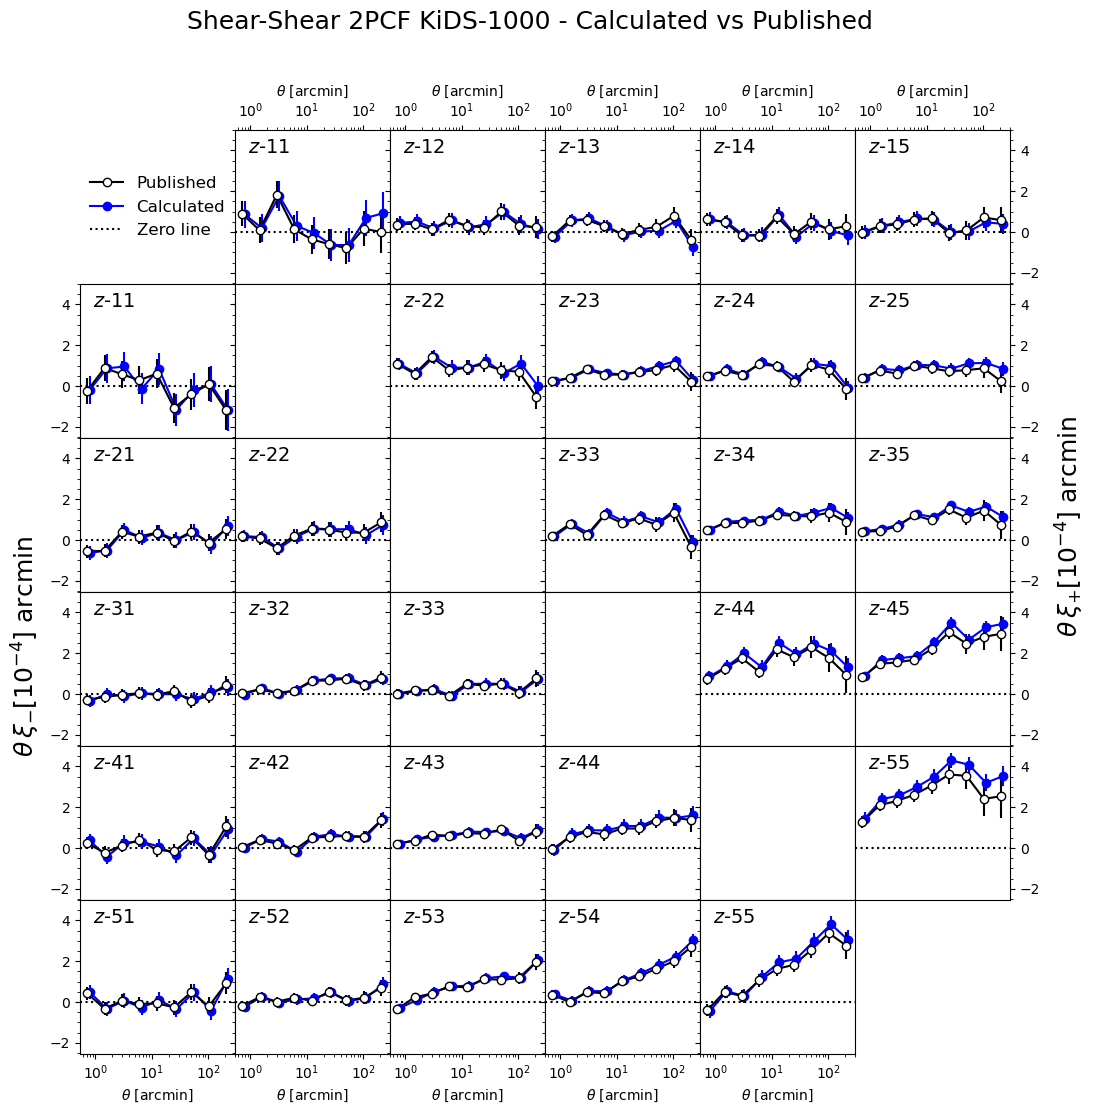

In [23]:
# Reproducing Fig. 5 of KiDS-1000 Cosmology
fig, ax = plt.subplots(6, 6, figsize = (12, 12), sharex = True, sharey = True, gridspec_kw = dict(wspace = 0, hspace = 0))

# Xi+
for i in range(5):
    for k, j in enumerate(range(i, 5)):
        g = gg_all[(i,j)]
        m_bias_fac = (1 + m_val[i]) * (1 + m_val[j])
        theta = g.meanr

        # Calculated 2PCF
        ax[i,j + 1].plot(theta, theta * g.xip * 1e4 * m_bias_fac, linewidth = 1.5, markersize = 5, label = 'Calculated', color = 'blue')
        ax[i,j + 1].errorbar(theta, theta * g.xip * 1e4 * m_bias_fac, yerr = theta * np.sqrt(g.varxip) * 1e4 * m_bias_fac, fmt = 'o', color = 'blue')
        
        # Published 2PCF
        mask = (pub_xip["BIN1"] == i + 1) & (pub_xip["BIN2"] == j + 1)
            

        ax[i,j + 1].plot(pub_xip["ANG"][mask], pub_xip["ANG"][mask] * pub_xip["VALUE"][mask] * 1e4, 'ko-', markerfacecolor = 'white', linewidth = 1.5, markersize = 5, label = 'Published')
        ax[i,j + 1].errorbar(pub_xip["ANG"][mask], pub_xip["ANG"][mask] * pub_xip["VALUE"][mask] * 1e4, yerr = pub_xip["ANG"][mask] * 1e4 * xip_err[start_indices[i][k] : start_indices[i][k] + 9], fmt = 'o', color = 'black', markerfacecolor = 'white')

        
        ax[i,j + 1].set_xscale("log")
        ax[i,j + 1].axhline(0,ls = ":", c = "k")
        ax[i, j + 1].text(0.08, 0.85, fr"$z$-{i+1}{j+1}", transform = ax[i, j + 1].transAxes, fontsize = 14)


# Xi-
for i in range(5):
    for j in range(i + 1):
        g = gg_all[(j, i)]
        m_bias_fac = (1 + m_val[j]) * (1 + m_val[i])

        theta = g.meanr

        # Calculated 2PCF
        ax[i + 1, j].plot(theta, theta * g.xim * 1e4 * m_bias_fac, linewidth = 1.5, markersize = 5, label = 'Calculated', color = 'blue')
        ax[i + 1, j].errorbar(theta, theta * g.xim * 1e4 * m_bias_fac, yerr = theta * np.sqrt(g.varxim) * 1e4 * m_bias_fac, fmt = 'o', color = 'blue')


        # Published 2PCF
        mask = (pub_xim["BIN1"] == j + 1) & (pub_xim["BIN2"] == i + 1)
            
        ax[i + 1, j].plot(pub_xim["ANG"][mask], pub_xim["ANG"][mask] * pub_xim["VALUE"][mask] * 1e4, 'ko-', markerfacecolor = 'white', linewidth = 1.5, markersize = 5, label = 'Published')
        ax[i + 1, j].errorbar(pub_xim["ANG"][mask], pub_xim["ANG"][mask] * pub_xim["VALUE"][mask] * 1e4, yerr = pub_xim["ANG"][mask] * 1e4 * xim_err[start_indices[j][i - j] : start_indices[j][i - j] + 9], fmt = 'o', color = 'black', markerfacecolor = 'white')

        ax[i + 1, j].set_xscale("log")
        ax[i + 1, j].axhline(0, ls = ":", c = "k")
        ax[i + 1, j].text(0.08, 0.85, fr"$z$-{i+1}{j+1}", transform = ax[i + 1, j].transAxes, fontsize = 14)


#Beautification!

ax[0, 0].axis("off")
ax[5, 5].axis("off")

legend_handles = [
    Line2D([0], [0], color = 'black', lw = 1.5, marker = 'o',
           markerfacecolor = 'white', label = 'Published'),
    Line2D([0], [0], color = 'blue', lw = 1.5, marker = 'o',
           label = 'Calculated'),
    Line2D([0], [0], color = 'black', ls = ':', label = 'Zero line')
]

ax[0,0].axis("off")
ax[0,0].legend(handles=legend_handles, loc = 'center', frameon = False, fontsize = 12)

fig.text(0.95, 0.55, r'$\theta\,\xi_{+}[10^{-4}]$ arcmin', rotation = 90, va = 'center', ha = 'center', fontsize = 18)
fig.text(0.08, 0.45, r'$\theta\,\xi_{-}[10^{-4}]$ arcmin', rotation = 90, va = 'center', ha = 'center', fontsize = 18)

for j in range(1, 6):
    ax[0, j].set_xlabel(r'$\theta$ [arcmin]')
    ax[0, j].xaxis.set_label_position('top')
    ax[0, j].minorticks_on()
    ax[0, j].tick_params(axis = 'x', which = 'major', top = True, labeltop = True, bottom = False, labelbottom = False)
    ax[0, j].tick_params(axis = 'x', which = 'minor', top = True, bottom = False)

for i in range(5):
    ax[i, 5].tick_params(axis = 'y', which = 'major', right = True, labelright = True, left = False, labelleft = False)
    ax[i, 5].tick_params(axis = 'y', which = 'minor', right = True, left = False)
    ax[i, 5].yaxis.set_ticks_position('right')

    if i != 0:
        ax[i, 5].tick_params(axis = 'x', which = 'both', bottom = False, top = False)

for j in range(5):
    ax[5, j].set_xlabel(r'$\theta$ [arcmin]')

plt.suptitle("Shear-Shear 2PCF KiDS-1000 - Calculated vs Published", fontsize = 18)
plt.savefig(fname = '/user/p5_group/MeharChawla/icts2026/Mehar-Chawla/Shear-Shear_all_tomo.PDF', bbox_inches = 'tight')

In [24]:
# SHEAR - PSF 2PCF calculation
#2PCF for individual tomographic bins

ggSuperCat_single_tomo_S_PSF = []
for i in tqdm(range(5)):
    print(f'Calculating 2PCF for tomographic bin-{i + 1}')
    cat_shear = treecorr.Catalog(f'/user/p5_group/MeharChawla/KiDS1000/KiDS1000_TOMO{i+1}.fits', ra_col = 'RAJ2000', dec_col = 'DECJ2000', ra_units = 'degrees', dec_units = 'degrees', g1_col = 'e_1_c_1', g2_col = 'e_2_c_2', w_col = 'weight')
    cat_PSF = treecorr.Catalog(f'/user/p5_group/MeharChawla/KiDS1000/KiDS1000_TOMO{i+1}.fits', ra_col = 'RAJ2000', dec_col = 'DECJ2000', ra_units = 'degrees', dec_units = 'degrees', g1_col = 'PSF_e1', g2_col = 'PSF_e2', w_col = 'weight')
    gg = treecorr.GGCorrelation(min_sep = 0.5, max_sep = 300., nbins = 9, sep_units = 'arcmin')
    gg.process(cat_shear, cat_PSF)
    ggSuperCat_single_tomo_S_PSF.append(gg)
    print(f'Finished calculating 2PCF for tomographic bin-{i + 1}')
    # print(f"Number of galaxies in the {z_range} tomographic bin is {count}")


  0%|                                                                                                     | 0/5 [00:00<?, ?it/s]

Calculating 2PCF for tomographic bin-1


 20%|██████████████████▌                                                                          | 1/5 [00:05<00:21,  5.29s/it]

Finished calculating 2PCF for tomographic bin-1
Calculating 2PCF for tomographic bin-2


 40%|█████████████████████████████████████▏                                                       | 2/5 [00:16<00:26,  8.76s/it]

...

Finished calculating 2PCF for tomographic bin-3
Calculating 2PCF for tomographic bin-4


 80%|██████████████████████████████████████████████████████████████████████████▍                  | 4/5 [00:54<00:15, 15.29s/it]

Finished calculating 2PCF for tomographic bin-4
Calculating 2PCF for tomographic bin-5


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:12<00:00, 14.49s/it]

Finished calculating 2PCF for tomographic bin-5


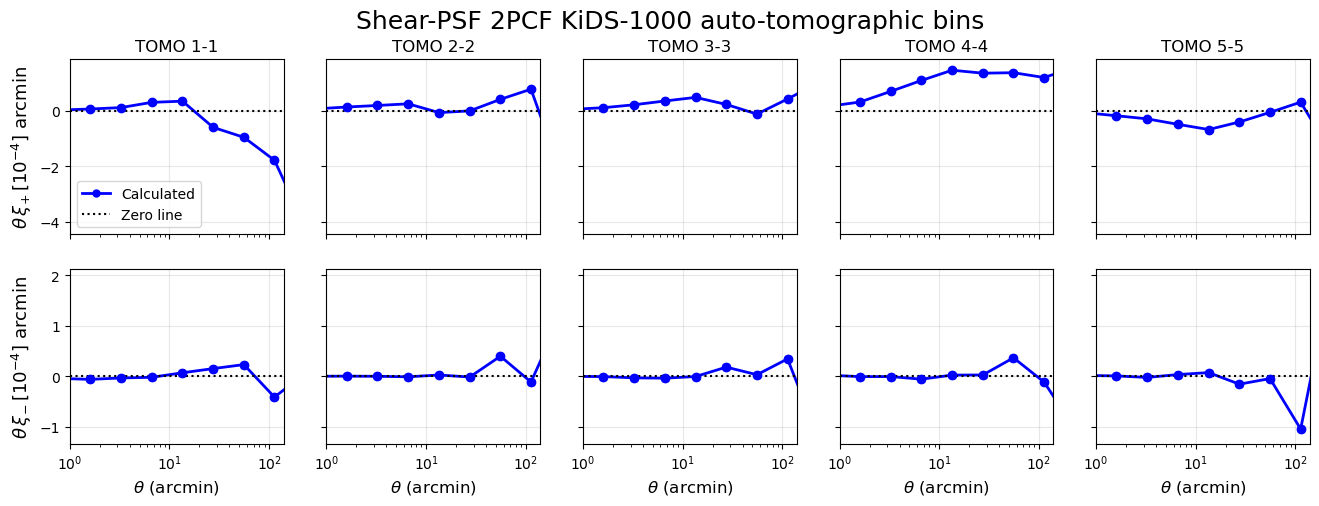

In [25]:
fig, ax = plt.subplots(2, 5, figsize = (16, 5), sharex = True, sharey = 'row')

for i in range(5):
    gg = ggSuperCat_single_tomo_S_PSF[i]
    
    # Xi+

    # Calculated 2PCF
    ax[0, i].semilogx(gg.meanr, gg.meanr * gg.xip * 1e4 * (1 + m_val[i]), 'o-', color = 'blue', linewidth = 2, markersize = 5, label = 'Calculated')
    ax[0, i].errorbar(gg.meanr, gg.meanr * gg.xip * 1e4 * (1 + m_val[i]), yerr = gg.meanr * 1e4 * np.sqrt(gg.varxip), fmt = 'o', color = 'blue')

    ax[0, i].axhline(0, ls = ":", c = "k", label = 'Zero line')

    ax[0, i].set_title(f"TOMO {i + 1}-{i + 1}")
    ax[0, i].grid(alpha = 0.3) 
    

    # Xi-

    # Calculated 2PCF
    ax[1, i].semilogx(gg.meanr, gg.meanr * gg.xim * 1e4 * (1 + m_val[i]), 's-', color = 'blue', linewidth = 2, markersize = 5, label = 'Calculated')
    ax[1, i].errorbar(gg.meanr, gg.meanr * gg.xim * 1e4 * (1 + m_val[i]), yerr = gg.meanr * 1e4 * np.sqrt(gg.varxim), fmt = 'o', color = 'blue')

    ax[1, i].axhline(0, ls = ":", c = "k")

    ax[1, i].grid(alpha = 0.3)

# Axis labels
ax[0, 0].set_ylabel(r'$\theta\,\xi_{+}\,[10^{-4}]$ arcmin', fontsize = 13)
ax[1, 0].set_ylabel(r'$\theta\,\xi_{-}\,[10^{-4}]$ arcmin', fontsize = 13)

ax[0, 0].legend()

for i in range(5):
    ax[1, i].set_xlabel(r'$\theta$ (arcmin)', fontsize = 12)

plt.suptitle('Shear-PSF 2PCF KiDS-1000 auto-tomographic bins', fontsize = 18)
plt.xlim(1, 140)
plt.savefig(fname = '/user/p5_group/MeharChawla/icts2026/Mehar-Chawla/Shear-PSF_auto_tomo.PDF', bbox_inches = 'tight')

In [48]:
"""
Function to randomly rotate a galaxy such that the magnitude of (complex) ellipticity doesn't change.
Takes a whole array of e_1 and e_2 ellipticities as inputs, or even singular values.
"""

def give_random_ellipticity(e_1, e_2):
    e_mod = np.sqrt(e_1**2 + e_2**2)
    phi_prime = np.random.uniform(0, np.pi, size = np.shape(e_mod))
    e_1_prime = e_mod * np.cos(2 * phi_prime)
    e_2_prime = e_mod * np.sin(2 * phi_prime)
    return e_1_prime, e_2_prime

In [45]:
# To apply the random rotations and create a new column in each of the 5 .fits files
# Making new files with the updated ellipticities

for i in tqdm(range(5)):
    filename = f"/user/p5_group/MeharChawla/KiDS1000/KiDS1000_TOMO{i + 1}.fits"

    with fits.open(filename) as hdul:
        e_1 = np.array(hdul[1].data['e1'])
        e_2 = np.array(hdul[1].data['e2'])
        w = np.array(hdul[1].data['weight'])

        e_1_prime, e_2_prime = give_random_ellipticity(e_1, e_2)

        c_1_prime = np.sum(w * e_1_prime) / np.sum(w)
        c_2_prime = np.sum(w * e_2_prime) / np.sum(w)

        e_1_c_1_prime = e_1_prime - c_1_prime
        e_2_c_2_prime = e_2_prime - c_2_prime

        new_cols = hdul[1].columns + fits.ColDefs([
            fits.Column(name = 'e_1_c_1_prime', format = 'D', array = e_1_c_1_prime),
            fits.Column(name = 'e_2_c_2_prime', format = 'D', array = e_2_c_2_prime)
        ])

        new_hdu = fits.BinTableHDU.from_columns(new_cols, header = hdul[1].header)

        hdul[1] = new_hdu

        new_filename = f"/user/p5_group/MeharChawla/KiDS1000/KiDS1000_TOMO{i + 1}_random_rotated.fits"
        hdul.writeto(new_filename, overwrite = True)


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [03:43<00:00, 44.66s/it]


In [51]:
#2PCF for individual tomographic bins

ggSuperCat_single_tomo = []
for i in tqdm(range(5)):
    print(f'Calculating 2PCF for tomographic bin-{i + 1}')
    cat = treecorr.Catalog(f'/user/p5_group/MeharChawla/KiDS1000/KiDS1000_TOMO{i+1}_random_rotated.fits', ra_col = 'RAJ2000', dec_col = 'DECJ2000', ra_units = 'degrees', dec_units = 'degrees', g1_col = 'e_1_c_1_prime', g2_col = 'e_2_c_2_prime', w_col = 'weight')
    gg = treecorr.GGCorrelation(min_sep = 0.5, max_sep = 300., nbins = 9, sep_units = 'arcmin')
    gg.process(cat)
    ggSuperCat_single_tomo.append(gg)
    print(f'Finished calculating 2PCF for tomographic bin-{i + 1}')
    # print(f"Number of galaxies in the {z_range} tomographic bin is {count}")

  0%|                                                                                                     | 0/5 [00:00<?, ?it/s]

Calculating 2PCF for tomographic bin-1


 20%|██████████████████▌                                                                          | 1/5 [00:01<00:06,  1.69s/it]

Finished calculating 2PCF for tomographic bin-1
Calculating 2PCF for tomographic bin-2


 40%|█████████████████████████████████████▏                                                       | 2/5 [00:05<00:07,  2.65s/it]

...

Finished calculating 2PCF for tomographic bin-3
Calculating 2PCF for tomographic bin-4


 80%|██████████████████████████████████████████████████████████████████████████▍                  | 4/5 [00:14<00:04,  4.00s/it]

Finished calculating 2PCF for tomographic bin-4
Calculating 2PCF for tomographic bin-5


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:19<00:00,  3.88s/it]

Finished calculating 2PCF for tomographic bin-5


In [53]:
#2PCF for cross tomographic bins

ggSuperCat_cross_tomo = []

for i in tqdm(range(5)):
    gg_temp = []
    for j in range(i + 1, 5):
        print(f'Calculating 2PCF for tomographic bin-{i + 1} and tomographic bin-{j + 1}')
        cat1 = treecorr.Catalog(f'/user/p5_group/MeharChawla/KiDS1000/KiDS1000_TOMO{i+1}_random_rotated.fits', ra_col = 'RAJ2000', dec_col = 'DECJ2000', ra_units = 'degrees', dec_units = 'degrees', g1_col = 'e_1_c_1_prime', g2_col = 'e_2_c_2_prime', w_col = 'weight')
        cat2 = treecorr.Catalog(f'/user/p5_group/MeharChawla/KiDS1000/KiDS1000_TOMO{j+1}_random_rotated.fits', ra_col = 'RAJ2000', dec_col = 'DECJ2000', ra_units = 'degrees', dec_units = 'degrees', g1_col = 'e_1_c_1_prime', g2_col = 'e_2_c_2_prime', w_col = 'weight')
        gg = treecorr.GGCorrelation(min_sep = 0.5, max_sep = 300., nbins = 9, sep_units = 'arcmin')
        gg.process(cat1, cat2)
        gg_temp.append(gg)
        print(f'Finished calculating 2PCF for tomographic bin-{i + 1} and tomographic bin-{j + 1}')
    ggSuperCat_cross_tomo.append(gg_temp)
    # print(f"Number of galaxies in the {z_range} tomographic bin is {count}")

  0%|                                                                                                     | 0/5 [00:00<?, ?it/s]

Calculating 2PCF for tomographic bin-1 and tomographic bin-2
Finished calculating 2PCF for tomographic bin-1 and tomographic bin-2
Calculating 2PCF for tomographic bin-1 and tomographic bin-3
Finished calculating 2PCF for tomographic bin-1 and tomographic bin-3
Calculating 2PCF for tomographic bin-1 and tomographic bin-4
Finished calculating 2PCF for tomographic bin-1 and tomographic bin-4
Calculating 2PCF for tomographic bin-1 and tomographic bin-5


 20%|██████████████████▌                                                                          | 1/5 [00:22<01:29, 22.28s/it]

Finished calculating 2PCF for tomographic bin-1 and tomographic bin-5
Calculating 2PCF for tomographic bin-2 and tomographic bin-3
Finished calculating 2PCF for tomographic bin-2 and tomographic bin-3
Calculating 2PCF for tomographic bin-2 and tomographic bin-4
Finished calculating 2PCF for tomographic bin-2 and tomographic bin-4
Calculating 2PCF for tomographic bin-2 and tomographic bin-5


 40%|█████████████████████████████████████▏                                                       | 2/5 [00:45<01:08, 22.89s/it]

Finished calculating 2PCF for tomographic bin-2 and tomographic bin-5
Calculating 2PCF for tomographic bin-3 and tomographic bin-4
Finished calculating 2PCF for tomographic bin-3 and tomographic bin-4
Calculating 2PCF for tomographic bin-3 and tomographic bin-5


 60%|███████████████████████████████████████████████████████▊                                     | 3/5 [01:04<00:42, 21.26s/it]

Finished calculating 2PCF for tomographic bin-3 and tomographic bin-5
Calculating 2PCF for tomographic bin-4 and tomographic bin-5


100%|█████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [01:14<00:00, 14.96s/it]

Finished calculating 2PCF for tomographic bin-4 and tomographic bin-5


In [54]:
# for i in range(5):
#     print(len(ggSuperCat_cross_tomo[i]))

fname = "/user/p5_lecturer/KiDS1000/KiDS1000_cosmis_shear_data_release/data_fits/xipm_KIDS1000_BlindC_with_m_bias_V1.0.0A_ugriZYJHKs_photoz_SG_mask_LF_svn_309c_2Dbins_v2_goldclasses_Flag_SOM_Fid.fits"

pub_xip = Table.read(fname, hdu = "xiP")
pub_xim = Table.read(fname, hdu = "xiM")

sigma = np.sqrt(np.diag(cov))
xip_err = sigma[:135]
xim_err = sigma[135:]

"""
starting indices, in the individual error matrices (xip_err and xim_err), are in jumps
    stored as:
    
    1-1 1-2 1-3 1-4 1-5  
    2-2 2-3 2-4 2-5       
    3-3 3-4 3-5           
    4-4 4-5               
    5-5                   

    Hence,
"""

start_indices = [
    [0, 9, 18, 27, 36], # 1-1, 1-2, 1-3, 1-4, 1-5 respectively
    [45, 54, 63, 72],
    [81, 90, 99],
    [108, 117],
    [126]
]

gg_all = {}
# Auto
for i in range(5):
    gg_all[(i, i)] = ggSuperCat_single_tomo[i]

# Cross
for i in range(5):
    for k, j in enumerate(range(i + 1, 5)):
        gg_all[(i, j)] = ggSuperCat_cross_tomo[i][k]

print(pub_xip)
print(pub_xim)

BIN1 BIN2 ANGBIN          VALUE                 ANG        
                                               arcmin      
---- ---- ------ ----------------------- ------------------
   1    1      1  0.00012511562543131703 0.7133649061081178
   1    1      2  6.0068356662917785e-06  1.452095610920429
   1    1      3     6.1931750226706e-05 2.9558247752305276
   1    1      4  2.1174242050056085e-06  6.016752640915019
   1    1      5  -2.928822558150438e-06 12.247448713915892
   1    1      6 -2.3899101204485857e-06 24.930391683376275
   1    1      7  -1.568898350973325e-06  50.74725716388292
   1    1      8   1.615415562263499e-07  103.2989831192456
   1    1      9 -3.2968259754405076e-09 210.27106704526634
 ...  ...    ...                     ...                ...
   4    5      9  1.4050195088237204e-06 210.27106704526634
   5    5      1  0.00017720232690063403 0.7133649061081178
   5    5      2   0.0001446351586479555  1.452095610920429
   5    5      3   7.802876747538117e-05

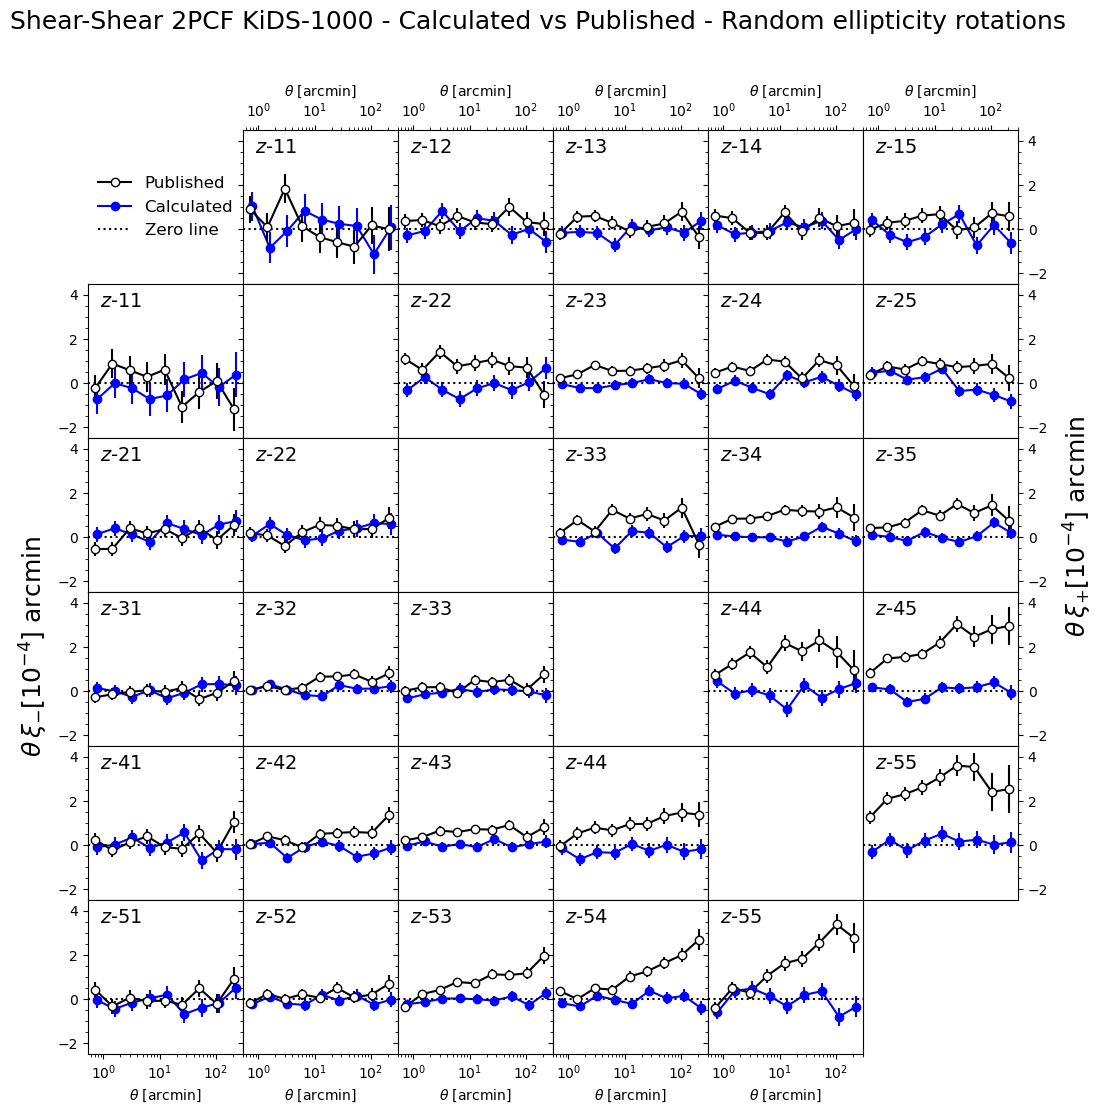

In [55]:
# Reproducing Fig. 5 of KiDS-1000 Cosmology
fig, ax = plt.subplots(6, 6, figsize = (12, 12), sharex = True, sharey = True, gridspec_kw = dict(wspace = 0, hspace = 0))

# Xi+
for i in range(5):
    for k, j in enumerate(range(i, 5)):
        g = gg_all[(i,j)]
        m_bias_fac = (1 + m_val[i]) * (1 + m_val[j])
        theta = g.meanr

        # Calculated 2PCF
        ax[i,j + 1].plot(theta, theta * g.xip * 1e4 * m_bias_fac, linewidth = 1.5, markersize = 5, label = 'Calculated', color = 'blue')
        ax[i,j + 1].errorbar(theta, theta * g.xip * 1e4 * m_bias_fac, yerr = theta * np.sqrt(g.varxip) * 1e4 * m_bias_fac, fmt = 'o', color = 'blue')
        
        # Published 2PCF
        mask = (pub_xip["BIN1"] == i + 1) & (pub_xip["BIN2"] == j + 1)
            

        ax[i,j + 1].plot(pub_xip["ANG"][mask], pub_xip["ANG"][mask] * pub_xip["VALUE"][mask] * 1e4, 'ko-', markerfacecolor = 'white', linewidth = 1.5, markersize = 5, label = 'Published')
        ax[i,j + 1].errorbar(pub_xip["ANG"][mask], pub_xip["ANG"][mask] * pub_xip["VALUE"][mask] * 1e4, yerr = pub_xip["ANG"][mask] * 1e4 * xip_err[start_indices[i][k] : start_indices[i][k] + 9], fmt = 'o', color = 'black', markerfacecolor = 'white')

        
        ax[i,j + 1].set_xscale("log")
        ax[i,j + 1].axhline(0,ls = ":", c = "k")
        ax[i, j + 1].text(0.08, 0.85, fr"$z$-{i+1}{j+1}", transform = ax[i, j + 1].transAxes, fontsize = 14)


# Xi-
for i in range(5):
    for j in range(i + 1):
        g = gg_all[(j, i)]
        m_bias_fac = (1 + m_val[j]) * (1 + m_val[i])

        theta = g.meanr

        # Calculated 2PCF
        ax[i + 1, j].plot(theta, theta * g.xim * 1e4 * m_bias_fac, linewidth = 1.5, markersize = 5, label = 'Calculated', color = 'blue')
        ax[i + 1, j].errorbar(theta, theta * g.xim * 1e4 * m_bias_fac, yerr = theta * np.sqrt(g.varxim) * 1e4 * m_bias_fac, fmt = 'o', color = 'blue')


        # Published 2PCF
        mask = (pub_xim["BIN1"] == j + 1) & (pub_xim["BIN2"] == i + 1)
            
        ax[i + 1, j].plot(pub_xim["ANG"][mask], pub_xim["ANG"][mask] * pub_xim["VALUE"][mask] * 1e4, 'ko-', markerfacecolor = 'white', linewidth = 1.5, markersize = 5, label = 'Published')
        ax[i + 1, j].errorbar(pub_xim["ANG"][mask], pub_xim["ANG"][mask] * pub_xim["VALUE"][mask] * 1e4, yerr = pub_xim["ANG"][mask] * 1e4 * xim_err[start_indices[j][i - j] : start_indices[j][i - j] + 9], fmt = 'o', color = 'black', markerfacecolor = 'white')

        ax[i + 1, j].set_xscale("log")
        ax[i + 1, j].axhline(0, ls = ":", c = "k")
        ax[i + 1, j].text(0.08, 0.85, fr"$z$-{i+1}{j+1}", transform = ax[i + 1, j].transAxes, fontsize = 14)


#Beautification!

ax[0, 0].axis("off")
ax[5, 5].axis("off")

legend_handles = [
    Line2D([0], [0], color = 'black', lw = 1.5, marker = 'o',
           markerfacecolor = 'white', label = 'Published'),
    Line2D([0], [0], color = 'blue', lw = 1.5, marker = 'o',
           label = 'Calculated'),
    Line2D([0], [0], color = 'black', ls = ':', label = 'Zero line')
]

ax[0,0].axis("off")
ax[0,0].legend(handles=legend_handles, loc = 'center', frameon = False, fontsize = 12)

fig.text(0.95, 0.55, r'$\theta\,\xi_{+}[10^{-4}]$ arcmin', rotation = 90, va = 'center', ha = 'center', fontsize = 18)
fig.text(0.08, 0.45, r'$\theta\,\xi_{-}[10^{-4}]$ arcmin', rotation = 90, va = 'center', ha = 'center', fontsize = 18)

for j in range(1, 6):
    ax[0, j].set_xlabel(r'$\theta$ [arcmin]')
    ax[0, j].xaxis.set_label_position('top')
    ax[0, j].minorticks_on()
    ax[0, j].tick_params(axis = 'x', which = 'major', top = True, labeltop = True, bottom = False, labelbottom = False)
    ax[0, j].tick_params(axis = 'x', which = 'minor', top = True, bottom = False)

for i in range(5):
    ax[i, 5].tick_params(axis = 'y', which = 'major', right = True, labelright = True, left = False, labelleft = False)
    ax[i, 5].tick_params(axis = 'y', which = 'minor', right = True, left = False)
    ax[i, 5].yaxis.set_ticks_position('right')

    if i != 0:
        ax[i, 5].tick_params(axis = 'x', which = 'both', bottom = False, top = False)

for j in range(5):
    ax[5, j].set_xlabel(r'$\theta$ [arcmin]')

plt.suptitle("Shear-Shear 2PCF KiDS-1000 - Calculated vs Published - Random ellipticity rotations", fontsize = 18)
plt.savefig(fname = '/user/p5_group/MeharChawla/icts2026/Mehar-Chawla/Shear-Shear_all_tomo_random_rotations.PDF', bbox_inches = 'tight')